Loading all patient data...
  Total rows: 1289
  Patients:   ['106', '116', '118', '119', '200', '201', '203', '207', '208', '209', '210', '213', '214', '215', '221', '222', '223', '228', '233']

Easy (n=11): ['215', '209', '210', '116', '233', '223', '221', '214', '228', '119', '106']
Hard  (n=8): ['118', '200', '201', '203', '207', '208', '213', '222']

--- Part 1: Entropy vs Regime ---


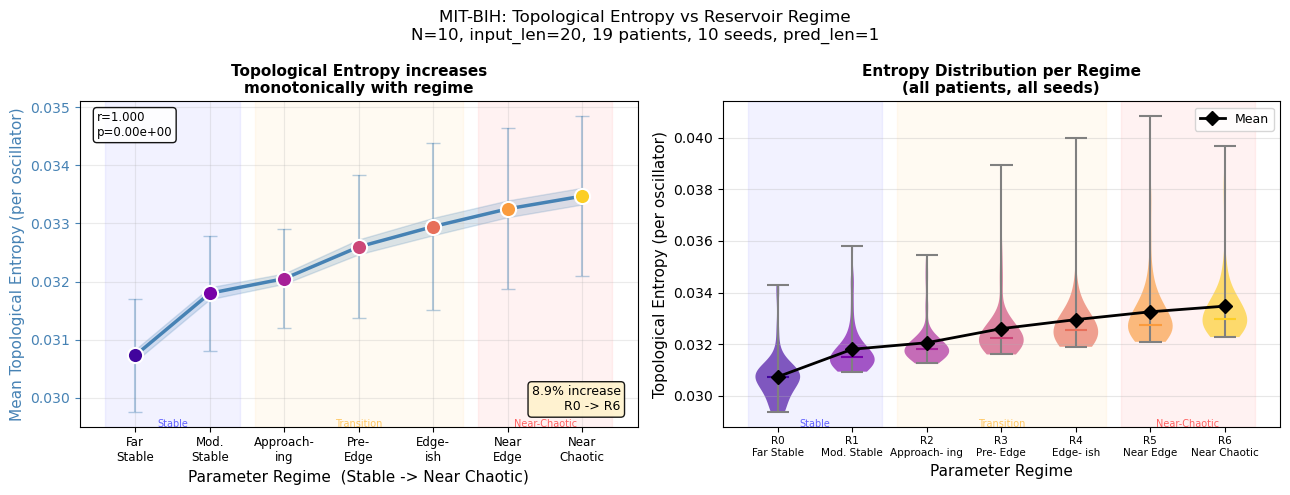

  Saved Fig1 (pred_len=1)  r=1.000 p=0.00e+00  8.9% increase


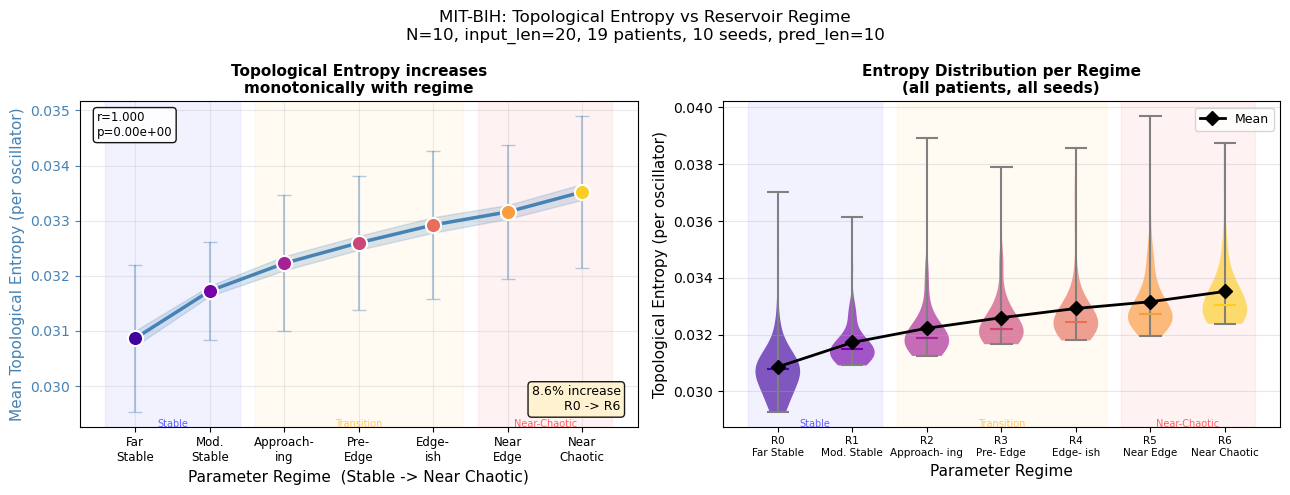

  Saved Fig1 (pred_len=10)  r=1.000 p=0.00e+00  8.6% increase

--- Part 2a: Single patient demo ---


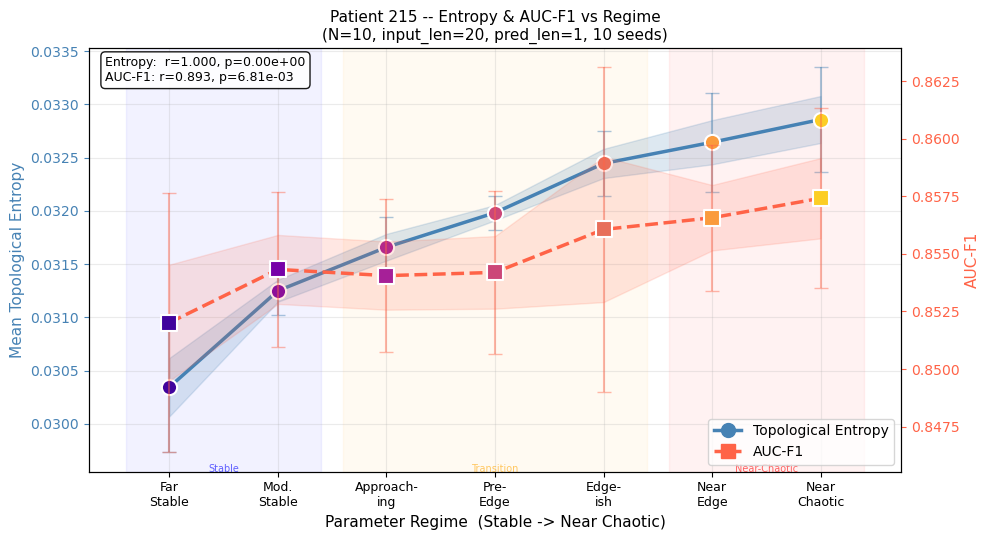

  Saved Fig2a (pred_len=1)


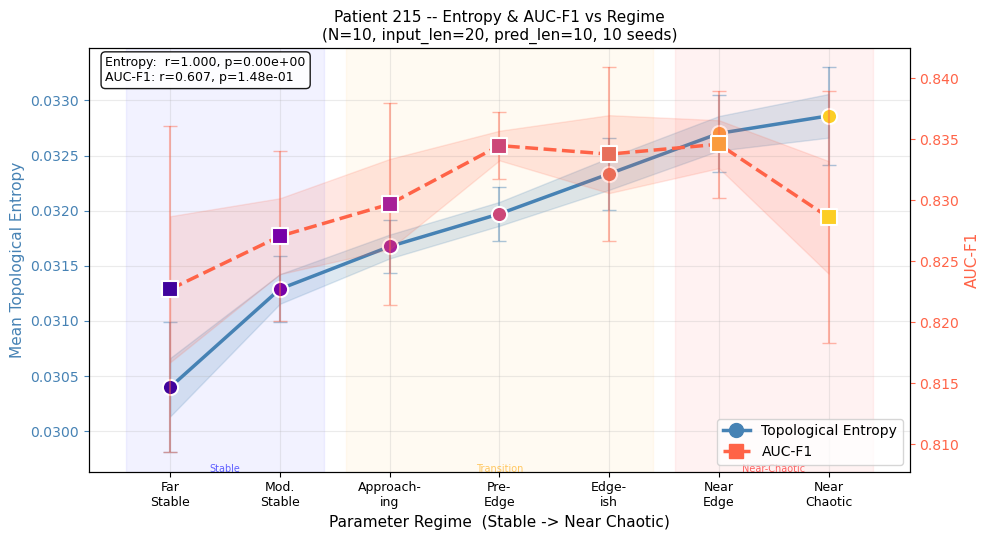

  Saved Fig2a (pred_len=10)

--- Part 2b: All patients ---


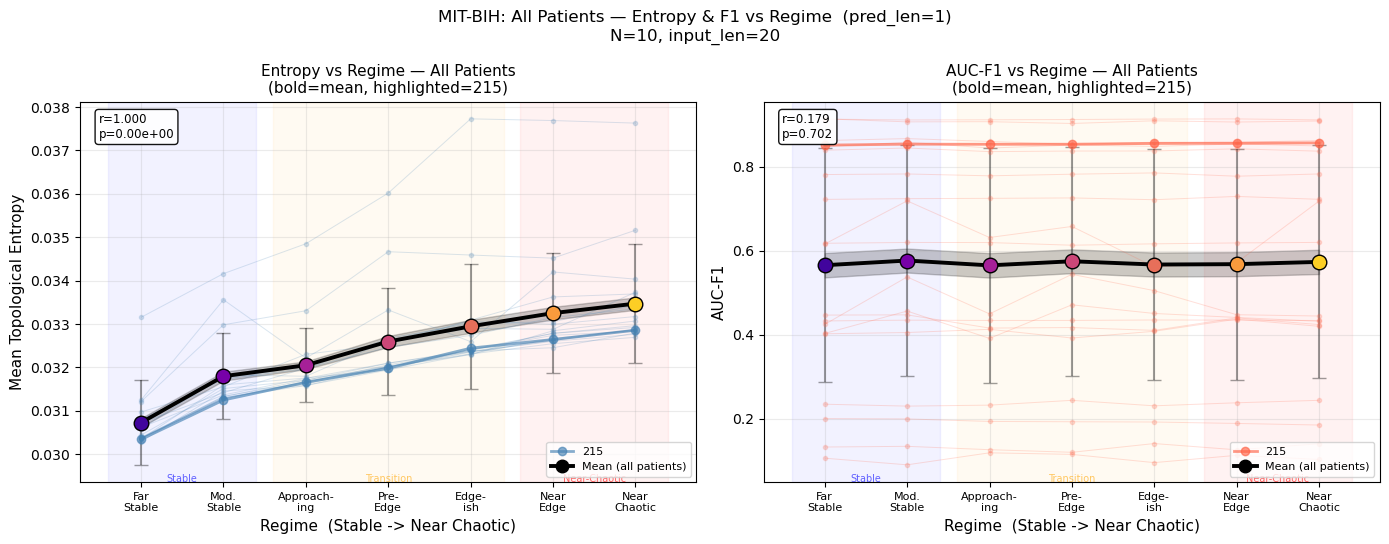

  Saved Fig2b (pred_len=1)


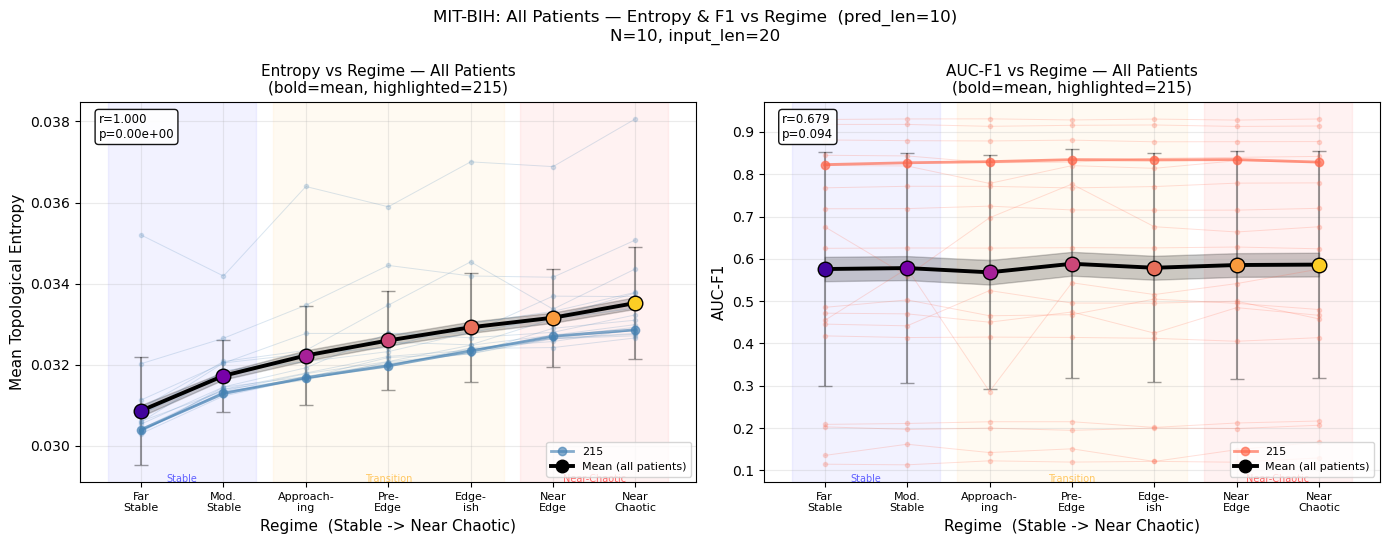

  Saved Fig2b (pred_len=10)

--- Part 3: Hard vs Easy interaction ---


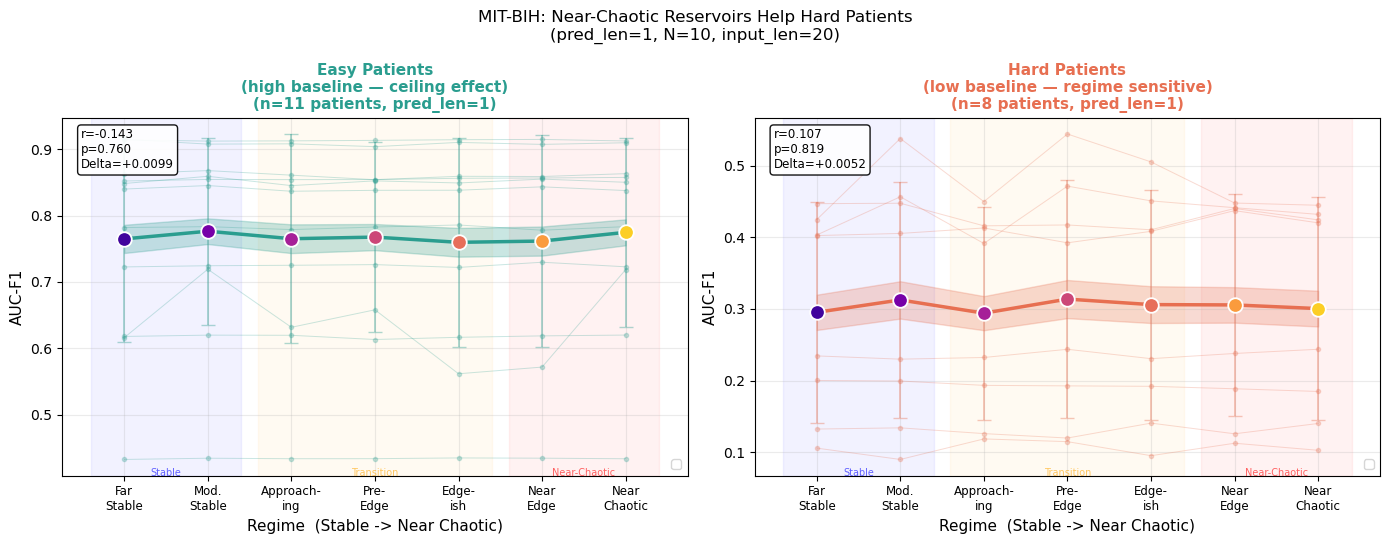

  Saved Fig3 (pred_len=1)


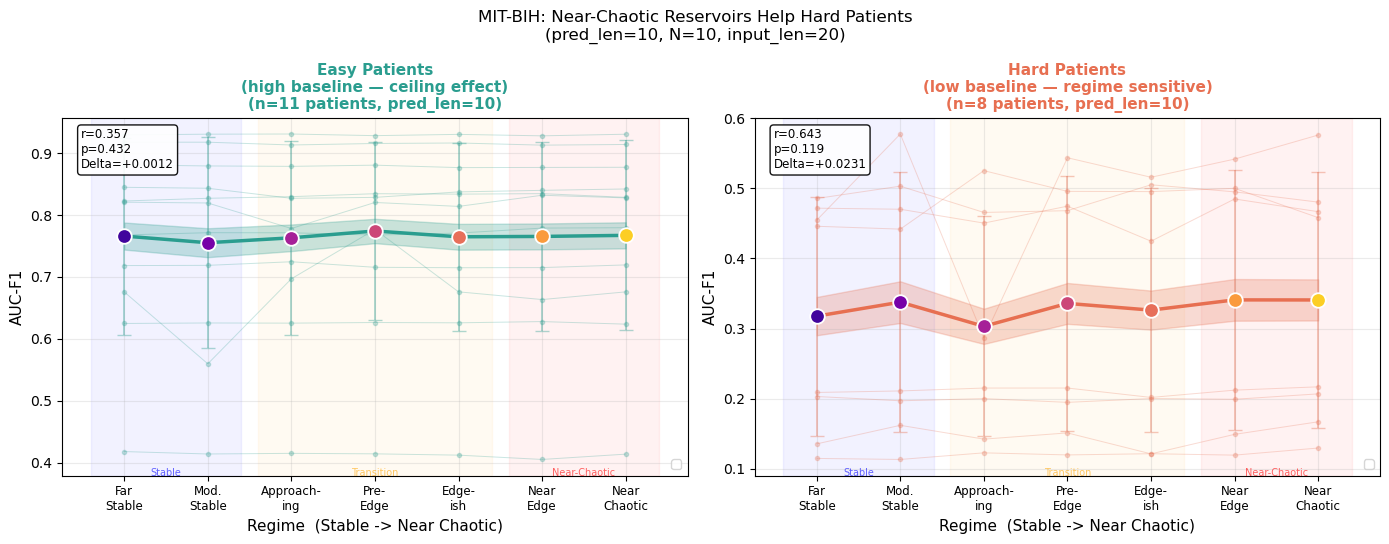

  Saved Fig3 (pred_len=10)

--- Publication Figure (pred_len=10) ---


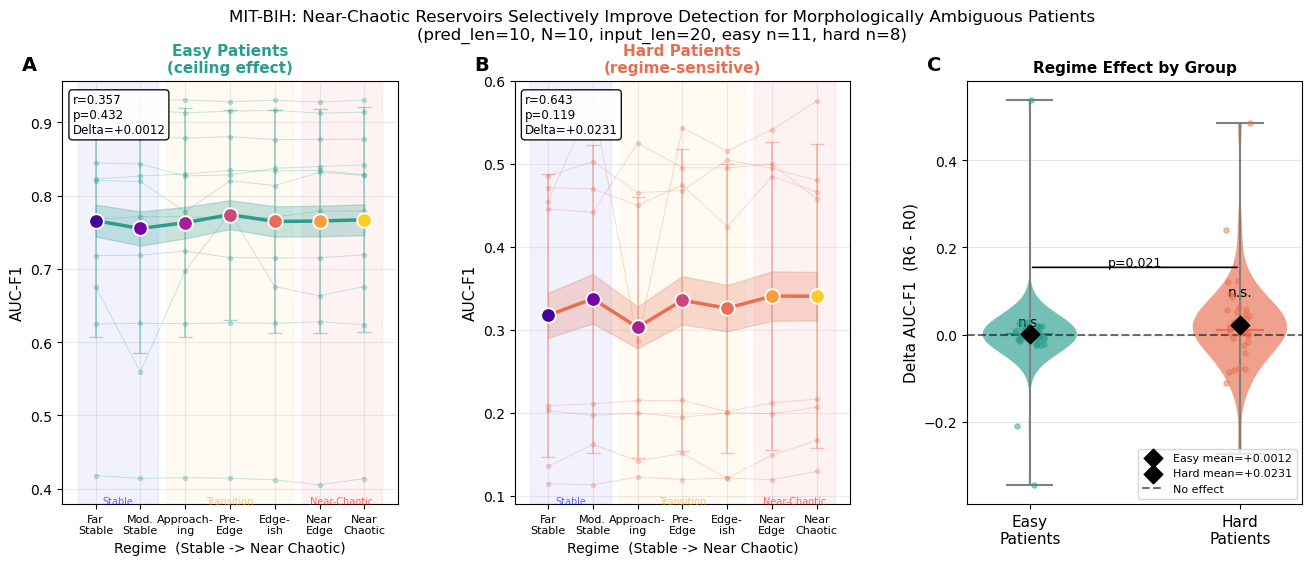

Saved publication figure

COMPLETE STATISTICS — MIT-BIH

--- Pred_len=1 ---
Entropy: r=1.0000, p=0.00e+00, 8.9% increase R0->R6
Easy | r=-0.1429 p=7.60e-01  Delta=+0.00989  mean_F1=0.7671  Wilcoxon_p=3.37e-01  frac_R6>R0=50.9%
Hard | r=0.1071 p=8.19e-01  Delta=+0.00522  mean_F1=0.3039  Wilcoxon_p=3.50e-01  frac_R6>R0=56.4%
Mann-Whitney (Easy delta vs Hard delta): p=6.41e-01

--- Pred_len=10 ---
Entropy: r=1.0000, p=0.00e+00, 8.6% increase R0->R6
Easy | r=0.3571 p=4.32e-01  Delta=+0.00116  mean_F1=0.7652  Wilcoxon_p=6.48e-01  frac_R6>R0=52.8%
Hard | r=0.6429 p=1.19e-01  Delta=+0.02307  mean_F1=0.3289  Wilcoxon_p=5.81e-02  frac_R6>R0=71.8%
Mann-Whitney (Easy delta vs Hard delta): p=2.11e-02

Patient groups:
  Easy: ['215', '209', '210', '116', '233', '223', '221', '214', '228', '119', '106']
  Hard: ['118', '200', '201', '203', '207', '208', '213', '222']


In [1]:
#!/usr/bin/env python
# coding: utf-8

# ==========================================================
# MIT-BIH: TOPOLOGICAL ENTROPY vs REGIME + F1 INTERACTION
# Matches exactly: save_dir, patients, N=10, input_len=10
# Analysis order:
#   Part 1 — Entropy increases with regime
#   Part 2 — F1 vs regime (single patient demo then all)
#   Part 3 — Hard vs easy patient interaction
# ==========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.stats import spearmanr, mannwhitneyu, wilcoxon
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CONFIG — match generator exactly
# ==========================================================

save_dir = "results_all_selected_patients_multiPara_seeds_newtopocalculation"

selected_patients = [
    '215', '213', '209', '203', '210', '116', '222', '233',
    '118', '223', '221', '214', '200', '228', '201', '208',
    '119', '207', '106'
]

DEMO_PATIENT      = '215'          # single patient for demo figures
random_data_seeds = [17]
random_res_seeds  = [1107, 1249, 1388, 1523, 1697, 1841, 1999, 2134, 2288, 2456]
FIXED_INPUT_LEN   = 20             # only value run
FIXED_N           = 10             # only value run
selected_regime_ids = list(range(7))
prediction_lengths  = [1, 10]

regime_labels = {
    0: "Far\nStable",    1: "Mod.\nStable",    2: "Approach-\ning",
    3: "Pre-\nEdge",     4: "Edge-\nish",       5: "Near\nEdge",
    6: "Near\nChaotic"
}
regime_labels_short = {k: v.replace('\n', ' ') for k, v in regime_labels.items()}

EASY_COLOR = "#2a9d8f"
HARD_COLOR = "#e76f51"

fig_dir = "figures_mitbih_entropy_f1_newcalculation"
os.makedirs(fig_dir, exist_ok=True)

regime_colors = cm.plasma(np.linspace(0.1, 0.9, 7))

# ==========================================================
# HELPERS
# ==========================================================

def extract_auc_f1(s):
    try:
        f1s = [r["f1"] for r in json.loads(s)]
        return np.trapz(f1s) / len(f1s)
    except Exception:
        return np.nan

def extract_early_f1(s, steps=15):
    try:
        results = json.loads(s)
        return results[min(steps, len(results)-1)]["f1"]
    except Exception:
        return np.nan

def load_data(patient_list):
    dfs = []
    for record in patient_list:
        for data_seed in random_data_seeds:
            for res_seed in random_res_seeds:
                for regime_id in selected_regime_ids:
                    csv_path = os.path.join(
                        save_dir,
                        "results_summary_online_detection_PCA_all_patient_"
                        "multiParaset_{}_data_seed_{}_res_seed_{}_"
                        "input_len_{}_reservoirs_{}_regime_id_{}.csv".format(
                            record, data_seed, res_seed,
                            FIXED_INPUT_LEN, FIXED_N, regime_id)
                    )
                    if os.path.exists(csv_path):
                        try:
                            df = pd.read_csv(csv_path)
                            if len(df) > 0:
                                dfs.append(df)
                        except Exception:
                            pass
    if not dfs:
        return pd.DataFrame()
    out = pd.concat(dfs, ignore_index=True)
    out["AUC_F1"]          = out["Online_results"].apply(extract_auc_f1)
    out["Early_F1"]        = out["Online_results"].apply(extract_early_f1)
    out["Neg_Detect_Time"] = -out["Avg_First_Detection_Time_Arrhythmic"]
    out["Regime_Label"]    = out["Regime_ID"].map(regime_labels_short)
    out["Patient"]         = out["Patient"].astype(str)   # fix int64 vs str mismatch
    return out

def add_background(ax):
    ax.axvspan(-0.4, 1.4, alpha=0.05, color='blue')
    ax.axvspan( 1.6, 4.4, alpha=0.05, color='orange')
    ax.axvspan( 4.6, 6.4, alpha=0.05, color='red')

def zone_text(ax):
    ylo = ax.get_ylim()[0]
    ax.text(0.5, ylo, 'Stable',       ha='center', fontsize=7, color='blue',   alpha=0.6)
    ax.text(3.0, ylo, 'Transition',   ha='center', fontsize=7, color='orange', alpha=0.6)
    ax.text(5.5, ylo, 'Near-Chaotic', ha='center', fontsize=7, color='red',    alpha=0.6)

def stat_box(ax, r, p, delta=None, loc=(0.03, 0.97)):
    p_str = "p={:.2e}".format(p) if p < 0.001 else "p={:.3f}".format(p)
    txt = "r={:.3f}\n{}".format(r, p_str)
    if delta is not None:
        txt += "\nDelta={:+.4f}".format(delta)
    ax.text(loc[0], loc[1], txt, transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.92))

def plot_regime_line(ax, grp, color, x_col="Regime_ID",
                     mean_col="mean", sem_col="sem", std_col=None,
                     per_pat_df=None, pat_col="Patient",
                     val_col="AUC_F1", thin_alpha=0.25,
                     bold_lw=2.5, show_scatter=True):
    x  = grp[x_col].values
    mu = grp[mean_col].values

    if per_pat_df is not None:
        for pat in per_pat_df[pat_col].unique():
            pg = per_pat_df[per_pat_df[pat_col]==pat].groupby(x_col)[val_col].mean()
            if len(pg) < 3:
                continue
            ax.plot(pg.index, pg.values, 'o-', color=color,
                    linewidth=0.7, markersize=3, alpha=thin_alpha, zorder=2)

    ax.plot(x, mu, 'o-', color=color, linewidth=bold_lw,
            markersize=9, zorder=5)
    ax.fill_between(x, mu - grp[sem_col], mu + grp[sem_col],
                    alpha=0.22, color=color)
    if std_col and std_col in grp.columns:
        ax.errorbar(x, mu, yerr=grp[std_col],
                    fmt='none', color=color, capsize=5,
                    linewidth=1.4, alpha=0.38)
    if show_scatter:
        for i, (xi, yi) in enumerate(zip(x, mu)):
            ax.scatter(xi, yi, color=regime_colors[i], s=110,
                       zorder=6, edgecolors='white', linewidths=1.3)

# ==========================================================
# LOAD DATA
# ==========================================================

print("Loading all patient data...")
df_all = load_data(selected_patients)
df_all = df_all.dropna(subset=["AUC_F1", "Avg_Topological_Entropy"])
print("  Total rows: {}".format(len(df_all)))
print("  Patients:   {}".format(sorted(df_all["Patient"].unique())))

if df_all.empty:
    raise RuntimeError("No data found. Check save_dir and filenames.")

df_demo = df_all[df_all["Patient"] == DEMO_PATIENT]

# ==========================================================
# PATIENT SPLIT: hard vs easy (data-driven, bottom/top third)
# ==========================================================

pat_median = df_all.groupby("Patient")["AUC_F1"].median().sort_values()
n_split    = len(pat_median) // 3
# HARD_PATIENTS = pat_median.head(n_split).index.tolist()
# EASY_PATIENTS = pat_median.tail(n_split).index.tolist()

# This is based on the anomaly detcttion results
HARD_PATIENTS = ['118', '200', '201', '203', '207', '208', '213', '222']
EASY_PATIENTS = [
    p for p in selected_patients
    if p not in HARD_PATIENTS
]

df_easy = df_all[df_all["Patient"].isin(EASY_PATIENTS)]
df_hard = df_all[df_all["Patient"].isin(HARD_PATIENTS)]

print("\nEasy (n={}): {}".format(len(EASY_PATIENTS), EASY_PATIENTS))
print("Hard  (n={}): {}".format(len(HARD_PATIENTS), HARD_PATIENTS))

# ==========================================================
# PART 1 — TOPOLOGICAL ENTROPY vs REGIME
# Fig 1a: line plot (mean ± SEM across all patients/seeds)
# Fig 1b: violin per regime
# ==========================================================

print("\n--- Part 1: Entropy vs Regime ---")

for pred_len in prediction_lengths:
    sub = df_all[df_all["Pred_len"] == pred_len]

    grp = sub.groupby("Regime_ID").agg(
        Mean_H=("Avg_Topological_Entropy", "mean"),
        Std_H =("Avg_Topological_Entropy", "std"),
        SEM_H =("Avg_Topological_Entropy", lambda x: x.std()/np.sqrt(len(x))),
    ).reset_index().sort_values("Regime_ID")

    x  = grp["Regime_ID"].values
    mu = grp["Mean_H"].values
    r_sp, p_sp = spearmanr(x, mu)
    lo, hi = mu[0], mu[-1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ---- Line plot ----
    ax = axes[0]
    add_background(ax)
    ax.fill_between(x, mu - grp["SEM_H"], mu + grp["SEM_H"],
                    alpha=0.2, color='steelblue')
    ax.plot(x, mu, 'o-', color='steelblue', linewidth=2.5, markersize=10, zorder=4)
    ax.errorbar(x, mu, yerr=grp["Std_H"],
                fmt='none', color='steelblue', capsize=5, linewidth=1.5, alpha=0.4)
    for i, (xi, yi) in enumerate(zip(x, mu)):
        ax.scatter(xi, yi, color=regime_colors[i], s=120,
                   zorder=5, edgecolors='white', linewidths=1.5)

    stat_box(ax, r_sp, p_sp)
    ax.text(0.97, 0.05,
            "{:.1f}% increase\nR0 -> R6".format(100*(hi-lo)/lo),
            transform=ax.transAxes, fontsize=9, ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', alpha=0.9))

    ax.set_xticks(x)
    ax.set_xticklabels([regime_labels[i] for i in x], fontsize=8.5)
    ax.set_xlabel("Parameter Regime  (Stable -> Near Chaotic)", fontsize=11)
    ax.set_ylabel("Mean Topological Entropy (per oscillator)",
                  fontsize=11, color='steelblue')
    ax.tick_params(axis='y', colors='steelblue')
    ax.set_title("Topological Entropy increases\nmonotonically with regime",
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.25)
    zone_text(ax)

    # ---- Violin plot ----
    ax = axes[1]
    add_background(ax)
    regime_ids = sorted(sub["Regime_ID"].unique())
    data_vio = [sub[sub["Regime_ID"]==r]["Avg_Topological_Entropy"].dropna().values
                for r in regime_ids]

    parts = ax.violinplot(data_vio, positions=regime_ids,
                          showmedians=True, showextrema=True, widths=0.6)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(regime_colors[i])
        pc.set_alpha(0.65)
    parts['cmedians'].set_colors([regime_colors[i] for i in regime_ids])
    for p in ['cbars','cmins','cmaxes']:
        parts[p].set_colors('gray')

    ax.plot(x, mu, 'D-', color='black', linewidth=2, markersize=7,
            zorder=5, label="Mean")

    ax.set_xticks(regime_ids)
    ax.set_xticklabels(["R{}\n{}".format(i, regime_labels_short[i])
                        for i in regime_ids], fontsize=7.5)
    ax.set_xlabel("Parameter Regime", fontsize=11)
    ax.set_ylabel("Topological Entropy (per oscillator)", fontsize=11)
    ax.set_title("Entropy Distribution per Regime\n(all patients, all seeds)",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    zone_text(ax)

    fig.suptitle(
        "MIT-BIH: Topological Entropy vs Reservoir Regime\n"
        "N={}, input_len={}, {} patients, {} seeds, pred_len={}".format(
            FIXED_N, FIXED_INPUT_LEN, len(selected_patients),
            len(random_res_seeds), pred_len),
        fontsize=12)
    plt.tight_layout()
    fname = "Fig1_entropy_vs_regime_predlen{}".format(pred_len)
    plt.savefig(os.path.join(fig_dir, fname+".pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir, fname+".png"), dpi=300, bbox_inches='tight')
    plt.show()
    print("  Saved Fig1 (pred_len={})  r={:.3f} p={:.2e}  {:.1f}% increase".format(
        pred_len, r_sp, p_sp, 100*(hi-lo)/lo))

# ==========================================================
# PART 2a — SINGLE PATIENT DEMO: dual-axis entropy + F1
# ==========================================================

print("\n--- Part 2a: Single patient demo ---")

grp_demo = df_demo.groupby(["Regime_ID","Pred_len"]).agg(
    Mean_H  =("Avg_Topological_Entropy","mean"),
    SEM_H   =("Avg_Topological_Entropy", lambda x: x.std()/np.sqrt(len(x))),
    Std_H   =("Avg_Topological_Entropy","std"),
    Mean_F1 =("AUC_F1","mean"),
    SEM_F1  =("AUC_F1", lambda x: x.std()/np.sqrt(len(x))),
    Std_F1  =("AUC_F1","std"),
).reset_index()

for pred_len in prediction_lengths:
    sub = grp_demo[grp_demo["Pred_len"]==pred_len].sort_values("Regime_ID")
    x     = sub["Regime_ID"].values
    xlbls = [regime_labels[i] for i in x]

    fig, ax1 = plt.subplots(figsize=(10, 5.5))
    ax2 = ax1.twinx()
    add_background(ax1)

    # Entropy left
    l1, = ax1.plot(x, sub["Mean_H"], 'o-', color='steelblue',
                   linewidth=2.5, markersize=10, zorder=4, label='Topological Entropy')
    ax1.fill_between(x, sub["Mean_H"]-sub["SEM_H"], sub["Mean_H"]+sub["SEM_H"],
                     alpha=0.18, color='steelblue')
    ax1.errorbar(x, sub["Mean_H"], yerr=sub["Std_H"],
                 fmt='none', color='steelblue', capsize=5, linewidth=1.5, alpha=0.45)
    for i, (xi, yi) in enumerate(zip(x, sub["Mean_H"])):
        ax1.scatter(xi, yi, color=regime_colors[i], s=120,
                    zorder=5, edgecolors='white', linewidths=1.5)

    # F1 right
    l2, = ax2.plot(x, sub["Mean_F1"], 's--', color='tomato',
                   linewidth=2.5, markersize=10, zorder=4, label='AUC-F1')
    ax2.fill_between(x, sub["Mean_F1"]-sub["SEM_F1"], sub["Mean_F1"]+sub["SEM_F1"],
                     alpha=0.15, color='tomato')
    ax2.errorbar(x, sub["Mean_F1"], yerr=sub["Std_F1"],
                 fmt='none', color='tomato', capsize=5, linewidth=1.5, alpha=0.45)
    for i, (xi, yi) in enumerate(zip(x, sub["Mean_F1"])):
        ax2.scatter(xi, yi, color=regime_colors[i], s=120,
                    zorder=5, marker='s', edgecolors='white', linewidths=1.5)

    r_h, p_h   = spearmanr(x, sub["Mean_H"])
    r_f1, p_f1 = spearmanr(x, sub["Mean_F1"])
    ax1.text(0.02, 0.98,
             "Entropy:  r={:.3f}, p={:.2e}\nAUC-F1: r={:.3f}, p={:.2e}".format(
                 r_h, p_h, r_f1, p_f1),
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.9))

    ax1.set_xticks(x)
    ax1.set_xticklabels(xlbls, fontsize=9)
    ax1.set_xlabel("Parameter Regime  (Stable -> Near Chaotic)", fontsize=11)
    ax1.set_ylabel("Mean Topological Entropy", fontsize=11, color='steelblue')
    ax2.set_ylabel("AUC-F1", fontsize=11, color='tomato')
    ax1.tick_params(axis='y', colors='steelblue')
    ax2.tick_params(axis='y', colors='tomato')
    ax1.legend(handles=[l1, l2], fontsize=10, loc='lower right')
    ax1.grid(True, alpha=0.25)
    zone_text(ax1)
    ax1.set_title(
        "Patient {} -- Entropy & AUC-F1 vs Regime\n"
        "(N={}, input_len={}, pred_len={}, {} seeds)".format(
            DEMO_PATIENT, FIXED_N, FIXED_INPUT_LEN, pred_len, len(random_res_seeds)),
        fontsize=11)

    plt.tight_layout()
    fname = "Fig2a_demo_patient_{}_predlen{}".format(DEMO_PATIENT, pred_len)
    plt.savefig(os.path.join(fig_dir, fname+".pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir, fname+".png"), dpi=300, bbox_inches='tight')
    plt.show()
    print("  Saved Fig2a (pred_len={})".format(pred_len))

# ==========================================================
# PART 2b — ALL PATIENTS: per-patient lines + bold mean
# ==========================================================

print("\n--- Part 2b: All patients ---")

for pred_len in prediction_lengths:
    sub_all = df_all[df_all["Pred_len"]==pred_len]

    grp_all = sub_all.groupby("Regime_ID").agg(
        mean_H  =("Avg_Topological_Entropy","mean"),
        sem_H   =("Avg_Topological_Entropy", lambda x: x.std()/np.sqrt(len(x))),
        std_H   =("Avg_Topological_Entropy","std"),
        mean_F1 =("AUC_F1","mean"),
        sem_F1  =("AUC_F1", lambda x: x.std()/np.sqrt(len(x))),
        std_F1  =("AUC_F1","std"),
    ).reset_index().sort_values("Regime_ID")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax, val_col, mean_col, sem_col, std_col, color, ylabel in [
        (axes[0], "Avg_Topological_Entropy",
         "mean_H", "sem_H", "std_H", "steelblue",
         "Mean Topological Entropy"),
        (axes[1], "AUC_F1",
         "mean_F1", "sem_F1", "std_F1", "tomato",
         "AUC-F1"),
    ]:
        add_background(ax)

        # Per-patient thin lines
        for pat in sub_all["Patient"].unique():
            pg = sub_all[sub_all["Patient"]==pat].groupby("Regime_ID")[val_col].mean()
            if len(pg) < 3:
                continue
            lw    = 2.0  if pat == DEMO_PATIENT else 0.7
            alpha = 0.65 if pat == DEMO_PATIENT else 0.2
            label = pat  if pat == DEMO_PATIENT else None
            ax.plot(pg.index, pg.values, 'o-', color=color,
                    linewidth=lw, markersize=3 if pat!=DEMO_PATIENT else 6,
                    alpha=alpha, zorder=3, label=label)

        # Bold mean
        x  = grp_all["Regime_ID"].values
        mu = grp_all[mean_col].values
        ax.plot(x, mu, 'o-', color='black', linewidth=2.8,
                markersize=9, zorder=6, label="Mean (all patients)")
        ax.fill_between(x,
                        mu - grp_all[sem_col],
                        mu + grp_all[sem_col],
                        alpha=0.2, color='black')
        ax.errorbar(x, mu, yerr=grp_all[std_col],
                    fmt='none', color='black', capsize=5,
                    linewidth=1.5, alpha=0.38)
        for i, (xi, yi) in enumerate(zip(x, mu)):
            ax.scatter(xi, yi, color=regime_colors[i], s=110,
                       zorder=7, edgecolors='black', linewidths=1)

        r_sp, p_sp = spearmanr(x, mu)
        stat_box(ax, r_sp, p_sp)

        ax.set_xticks(x)
        ax.set_xticklabels([regime_labels[i] for i in x], fontsize=8)
        ax.set_xlabel("Regime  (Stable -> Near Chaotic)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='lower right')
        zone_text(ax)

    axes[0].set_title("Entropy vs Regime — All Patients\n(bold=mean, highlighted={})"
                      .format(DEMO_PATIENT), fontsize=11)
    axes[1].set_title("AUC-F1 vs Regime — All Patients\n(bold=mean, highlighted={})"
                      .format(DEMO_PATIENT), fontsize=11)
    fig.suptitle(
        "MIT-BIH: All Patients — Entropy & F1 vs Regime  (pred_len={})\n"
        "N={}, input_len={}".format(pred_len, FIXED_N, FIXED_INPUT_LEN),
        fontsize=12)
    plt.tight_layout()
    fname = "Fig2b_all_patients_predlen{}".format(pred_len)
    plt.savefig(os.path.join(fig_dir, fname+".pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir, fname+".png"), dpi=300, bbox_inches='tight')
    plt.show()
    print("  Saved Fig2b (pred_len={})".format(pred_len))

# ==========================================================
# PART 3 — HARD vs EASY INTERACTION
# Fig 3: AUC-F1 vs regime per group
# Fig 4: Delta violin (R6-R0) hard vs easy
# Fig 5: Combined 3-panel publication figure
# ==========================================================

print("\n--- Part 3: Hard vs Easy interaction ---")

# ---- Fig 3: side-by-side AUC-F1 vs regime ----
for pred_len in prediction_lengths:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    deltas = {}

    for ax, df_sub, label, color in [
        (axes[0], df_easy, "Easy Patients\n(high baseline — ceiling effect)", EASY_COLOR),
        (axes[1], df_hard, "Hard Patients\n(low baseline — regime sensitive)",  HARD_COLOR),
    ]:
        sub = df_sub[df_sub["Pred_len"]==pred_len]
        grp = sub.groupby("Regime_ID")["AUC_F1"].agg(
            mean="mean",
            sem =lambda x: x.std()/np.sqrt(len(x)),
            std ="std"
        ).reset_index().sort_values("Regime_ID")

        if len(grp) == 0:
            ax.set_title("{}\n(no data)".format(label), fontsize=11,
                         color=color, fontweight='bold')
            continue

        x  = grp["Regime_ID"].values
        mu = grp["mean"].values

        add_background(ax)

        for pat in sub["Patient"].unique():
            pg = sub[sub["Patient"]==pat].groupby("Regime_ID")["AUC_F1"].mean()
            if len(pg) < 2:
                continue
            ax.plot(pg.index, pg.values, 'o-', color=color,
                    linewidth=0.7, markersize=3, alpha=0.25, zorder=2)

        ax.plot(x, mu, 'o-', color=color, linewidth=2.5, markersize=9, zorder=5)
        ax.fill_between(x, mu-grp["sem"], mu+grp["sem"], alpha=0.25, color=color)
        ax.errorbar(x, mu, yerr=grp["std"], fmt='none', color=color,
                    capsize=5, linewidth=1.4, alpha=0.38)
        for i, (xi, yi) in enumerate(zip(x, mu)):
            ax.scatter(xi, yi, color=regime_colors[i], s=110,
                       zorder=6, edgecolors='white', linewidths=1.3)

        r_sp, p_sp = spearmanr(x, mu)
        delta = mu[-1] - mu[0] if len(mu) > 1 else 0.0
        stat_box(ax, r_sp, p_sp, delta=delta)

        ax.set_xticks(x)
        ax.set_xticklabels([regime_labels[i] for i in x], fontsize=8.5)
        ax.set_xlabel("Regime  (Stable -> Near Chaotic)", fontsize=11)
        ax.set_ylabel("AUC-F1", fontsize=11)
        ax.set_title(label+"\n(n={} patients, pred_len={})".format(
            len(sub["Patient"].unique()), pred_len),
            fontsize=11, color=color, fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(True, alpha=0.25)
        zone_text(ax)

        # collect deltas
        r0 = sub[sub["Regime_ID"]==0].set_index(["Patient","Reservoir_seed"])["AUC_F1"]
        r6 = sub[sub["Regime_ID"]==6].set_index(["Patient","Reservoir_seed"])["AUC_F1"]
        common = r0.index.intersection(r6.index)
        if len(common) > 0:
            key = "Easy" if color==EASY_COLOR else "Hard"
            deltas[key] = (r6.loc[common] - r0.loc[common]).values

    fig.suptitle(
        "MIT-BIH: Near-Chaotic Reservoirs Help Hard Patients\n"
        "(pred_len={}, N={}, input_len={})".format(pred_len, FIXED_N, FIXED_INPUT_LEN),
        fontsize=12)
    plt.tight_layout()
    fname = "Fig3_easy_vs_hard_predlen{}".format(pred_len)
    plt.savefig(os.path.join(fig_dir, fname+".pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir, fname+".png"), dpi=300, bbox_inches='tight')
    plt.show()
    print("  Saved Fig3 (pred_len={})".format(pred_len))

# ==========================================================
# PUBLICATION FIGURE — 3-panel (best pred_len)
# Panel A: Easy AUC-F1 vs regime
# Panel B: Hard AUC-F1 vs regime
# Panel C: Delta violin
# ==========================================================

TARGET_PRED_LEN = 10   # use whichever shows clearest effect

print("\n--- Publication Figure (pred_len={}) ---".format(TARGET_PRED_LEN))

fig = plt.figure(figsize=(16, 5.5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)
ax_e = fig.add_subplot(gs[0])
ax_h = fig.add_subplot(gs[1])
ax_d = fig.add_subplot(gs[2])

for lbl, ax in zip(['A','B','C'], [ax_e, ax_h, ax_d]):
    ax.text(-0.12, 1.06, lbl, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')

deltas_pub = {}

for ax, df_sub, label, color in [
    (ax_e, df_easy, "Easy Patients\n(ceiling effect)", EASY_COLOR),
    (ax_h, df_hard, "Hard Patients\n(regime-sensitive)", HARD_COLOR),
]:
    sub = df_sub[df_sub["Pred_len"]==TARGET_PRED_LEN]
    grp = sub.groupby("Regime_ID")["AUC_F1"].agg(
        mean="mean",
        sem =lambda x: x.std()/np.sqrt(len(x)),
        std ="std"
    ).reset_index().sort_values("Regime_ID")

    if len(grp) == 0:
        ax.set_title("{}\n(no data)".format(label), fontsize=11,
                     color=color, fontweight='bold')
        continue

    x  = grp["Regime_ID"].values
    mu = grp["mean"].values

    add_background(ax)
    for pat in sub["Patient"].unique():
        pg = sub[sub["Patient"]==pat].groupby("Regime_ID")["AUC_F1"].mean()
        if len(pg) < 2:
            continue
        ax.plot(pg.index, pg.values, 'o-', color=color,
                linewidth=0.7, markersize=3, alpha=0.25, zorder=2)

    ax.plot(x, mu, 'o-', color=color, linewidth=2.5, markersize=9, zorder=5)
    ax.fill_between(x, mu-grp["sem"], mu+grp["sem"], alpha=0.25, color=color)
    ax.errorbar(x, mu, yerr=grp["std"], fmt='none', color=color,
                capsize=5, linewidth=1.4, alpha=0.38)
    for i, (xi, yi) in enumerate(zip(x, mu)):
        ax.scatter(xi, yi, color=regime_colors[i], s=110,
                   zorder=6, edgecolors='white', linewidths=1.3)

    r_sp, p_sp = spearmanr(x, mu)
    delta = mu[-1] - mu[0] if len(mu) > 1 else 0.0
    stat_box(ax, r_sp, p_sp, delta=delta)

    ax.set_xticks(x)
    ax.set_xticklabels([regime_labels[i] for i in x], fontsize=8)
    ax.set_xlabel("Regime  (Stable -> Near Chaotic)", fontsize=10)
    ax.set_ylabel("AUC-F1", fontsize=11)
    ax.set_title(label, fontsize=11, color=color, fontweight='bold')
    ax.grid(True, alpha=0.25)
    zone_text(ax)

    r0 = sub[sub["Regime_ID"]==0].set_index(["Patient","Reservoir_seed"])["AUC_F1"]
    r6 = sub[sub["Regime_ID"]==6].set_index(["Patient","Reservoir_seed"])["AUC_F1"]
    common = r0.index.intersection(r6.index)
    if len(common) > 0:
        key = "Easy" if color==EASY_COLOR else "Hard"
        deltas_pub[key] = (r6.loc[common] - r0.loc[common]).values
# Panel C: delta violin
ax = ax_d
if "Easy" in deltas_pub and "Hard" in deltas_pub:
    d_e = deltas_pub["Easy"]
    d_h = deltas_pub["Hard"]

    parts = ax.violinplot([d_e, d_h], positions=[0,1],
                          showmedians=True, showextrema=True, widths=0.45)
    parts['bodies'][0].set_facecolor(EASY_COLOR)
    parts['bodies'][1].set_facecolor(HARD_COLOR)
    for pc in parts['bodies']:
        pc.set_alpha(0.65)
    parts['cmedians'].set_colors([EASY_COLOR, HARD_COLOR])
    for p in ['cbars','cmins','cmaxes']:
        parts[p].set_colors('gray')

    rng = np.random.default_rng(42)
    ax.scatter(0+rng.uniform(-0.07,0.07,len(d_e)), d_e,
               color=EASY_COLOR, s=14, alpha=0.45, zorder=4)
    ax.scatter(1+rng.uniform(-0.07,0.07,len(d_h)), d_h,
               color=HARD_COLOR, s=14, alpha=0.45, zorder=4)
    ax.scatter([0],[d_e.mean()], color='black', s=90, zorder=7, marker='D',
               label="Easy mean={:+.4f}".format(d_e.mean()))
    ax.scatter([1],[d_h.mean()], color='black', s=90, zorder=7, marker='D',
               label="Hard mean={:+.4f}".format(d_h.mean()))
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5,
               alpha=0.55, label="No effect")

    _, p_mw = mannwhitneyu(d_e, d_h, alternative='two-sided')
    y_top = max(np.percentile(d_e,95), np.percentile(d_h,95)) * 1.15
    ax.annotate("", xy=(1,y_top), xytext=(0,y_top),
                arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
    p_str = "p={:.2e}".format(p_mw) if p_mw<0.001 else "p={:.3f}".format(p_mw)
    ax.text(0.5, y_top*1.02, p_str, ha='center', fontsize=9)

    # Within-group Wilcoxon
    for xi, d in [(0, d_e), (1, d_h)]:
        if len(d) > 5:
            try:
                _, p_wx = wilcoxon(d)
                star = "***" if p_wx<0.001 else "**" if p_wx<0.01 \
                       else "*" if p_wx<0.05 else "n.s."
                ax.text(xi, np.percentile(d,88), star,
                        ha='center', fontsize=10)
            except Exception:
                pass

ax.set_xticks([0,1])
ax.set_xticklabels(["Easy\nPatients","Hard\nPatients"], fontsize=11)
ax.set_ylabel("Delta AUC-F1  (R6 - R0)", fontsize=11)
ax.set_title("Regime Effect by Group", fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    "MIT-BIH: Near-Chaotic Reservoirs Selectively Improve Detection "
    "for Morphologically Ambiguous Patients\n"
    "(pred_len={}, N={}, input_len={}, easy n={}, hard n={})".format(
        TARGET_PRED_LEN, FIXED_N, FIXED_INPUT_LEN,
        len(EASY_PATIENTS), len(HARD_PATIENTS)),
    fontsize=12, y=1.01)

plt.savefig(os.path.join(fig_dir, "Fig4_publication_interaction.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "Fig4_publication_interaction.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved publication figure")

# ==========================================================
# FULL STATS BLOCK
# ==========================================================

print("\n" + "="*60)
print("COMPLETE STATISTICS — MIT-BIH")
print("="*60)

for pred_len in prediction_lengths:
    print("\n--- Pred_len={} ---".format(pred_len))
    sub = df_all[df_all["Pred_len"]==pred_len]

    # Entropy
    grp_h = sub.groupby("Regime_ID")["Avg_Topological_Entropy"].mean()
    r_h, p_h = spearmanr(grp_h.index, grp_h.values)
    lo, hi = grp_h.iloc[0], grp_h.iloc[-1]
    print("Entropy: r={:.4f}, p={:.2e}, {:.1f}% increase R0->R6".format(
        r_h, p_h, 100*(hi-lo)/lo))

    # F1 per group
    for df_sub, label in [(df_easy,"Easy"),(df_hard,"Hard")]:
        sub_g = df_sub[df_sub["Pred_len"]==pred_len]
        grp_f = sub_g.groupby("Regime_ID")["AUC_F1"].mean()
        r_f, p_f = spearmanr(grp_f.index, grp_f.values)
        delta = grp_f.iloc[-1] - grp_f.iloc[0]

        r0v = sub_g[sub_g["Regime_ID"]==0].set_index(
            ["Patient","Reservoir_seed"])["AUC_F1"]
        r6v = sub_g[sub_g["Regime_ID"]==6].set_index(
            ["Patient","Reservoir_seed"])["AUC_F1"]
        common = r0v.index.intersection(r6v.index)
        diff = (r6v.loc[common] - r0v.loc[common]).values
        p_wx = wilcoxon(diff)[1] if len(diff)>5 else np.nan
        frac = 100*np.mean(diff>0) if len(diff)>0 else np.nan

        print("{} | r={:.4f} p={:.2e}  Delta={:+.5f}  "
              "mean_F1={:.4f}  Wilcoxon_p={:.2e}  frac_R6>R0={:.1f}%".format(
                  label, r_f, p_f, delta, grp_f.mean(), p_wx, frac))

    # Between-group Mann-Whitney on deltas
    d_e_all, d_h_all = [], []
    for df_sub, store in [(df_easy,d_e_all),(df_hard,d_h_all)]:
        sub_g = df_sub[df_sub["Pred_len"]==pred_len]
        r0v = sub_g[sub_g["Regime_ID"]==0].set_index(
            ["Patient","Reservoir_seed"])["AUC_F1"]
        r6v = sub_g[sub_g["Regime_ID"]==6].set_index(
            ["Patient","Reservoir_seed"])["AUC_F1"]
        common = r0v.index.intersection(r6v.index)
        store.extend((r6v.loc[common]-r0v.loc[common]).values.tolist())
    if d_e_all and d_h_all:
        _, p_mw = mannwhitneyu(d_e_all, d_h_all, alternative='two-sided')
        print("Mann-Whitney (Easy delta vs Hard delta): p={:.2e}".format(p_mw))

print("\nPatient groups:")
print("  Easy: {}".format(EASY_PATIENTS))
print("  Hard: {}".format(HARD_PATIENTS))